##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
day_case = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Day_Case_Unit_TimeSeries.csv")

In [3]:
day_case.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
day_case["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [19]:
results = []

for hospital in day_case["hospital_id"].unique():
    hospital_data = (day_case[day_case["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for Day Case Unit Occupied Beds")
adf_results

ADF Test Results for Day Case Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-4.0368,0.0012,Yes
1,HHN-EDI-01,-8.8118,0.0000,Yes
2,HHN-LON-01,-4.9636,0.0000,Yes
3,HHN-LON-02,-4.9967,0.0000,Yes
4,HHN-MAN-01,-6.7200,0.0000,Yes


     All five Day Case Units in each hospital have stationary data.
     P-values are below 0.05, confirming statistical significance.
     Bed occupancy returns to a stable average over time.
     No differencing is required before forecasting.
     The data is suitable for models such as ARIMA(1,0,0) or ARIMA(2,0,0).

- Autocorrelation (ACF) for all hospitals

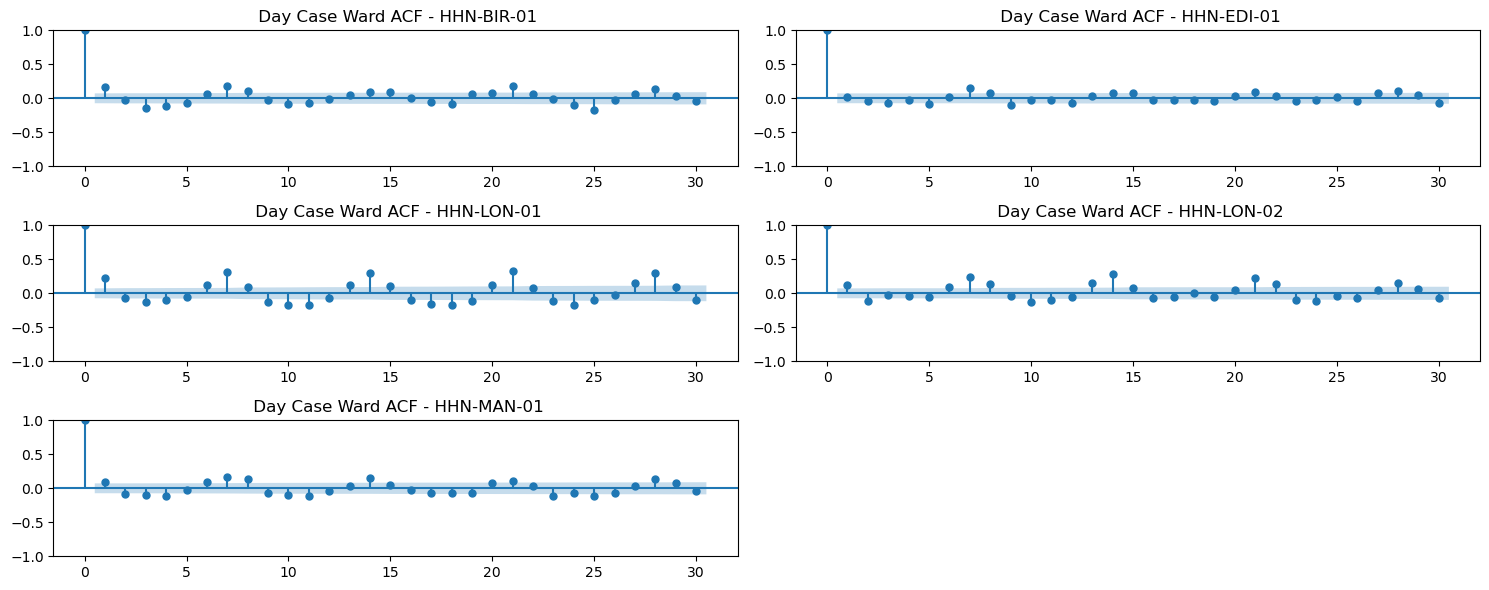

In [20]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(day_case["hospital_id"].unique())):

    hospital_data = (day_case[day_case["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f" Day Case Ward ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     Day Case Units have very little day-to-day memory.
     Yesterday's occupancy has minimal influence on today's occupancy.
     A strong weekly (7-day) pattern is present across all hospitals.
     Weekly schedules and planned procedures are the main drivers of occupancy.
     London hospitals show the strongest weekly seasonal pattern.
     A Seasonal ARIMA (SARIMA) model with a 7-day seasonal period is more suitable than a standard ARIMA model for forecasting Day Case Unit occupancy.

- PACF for all hospitals

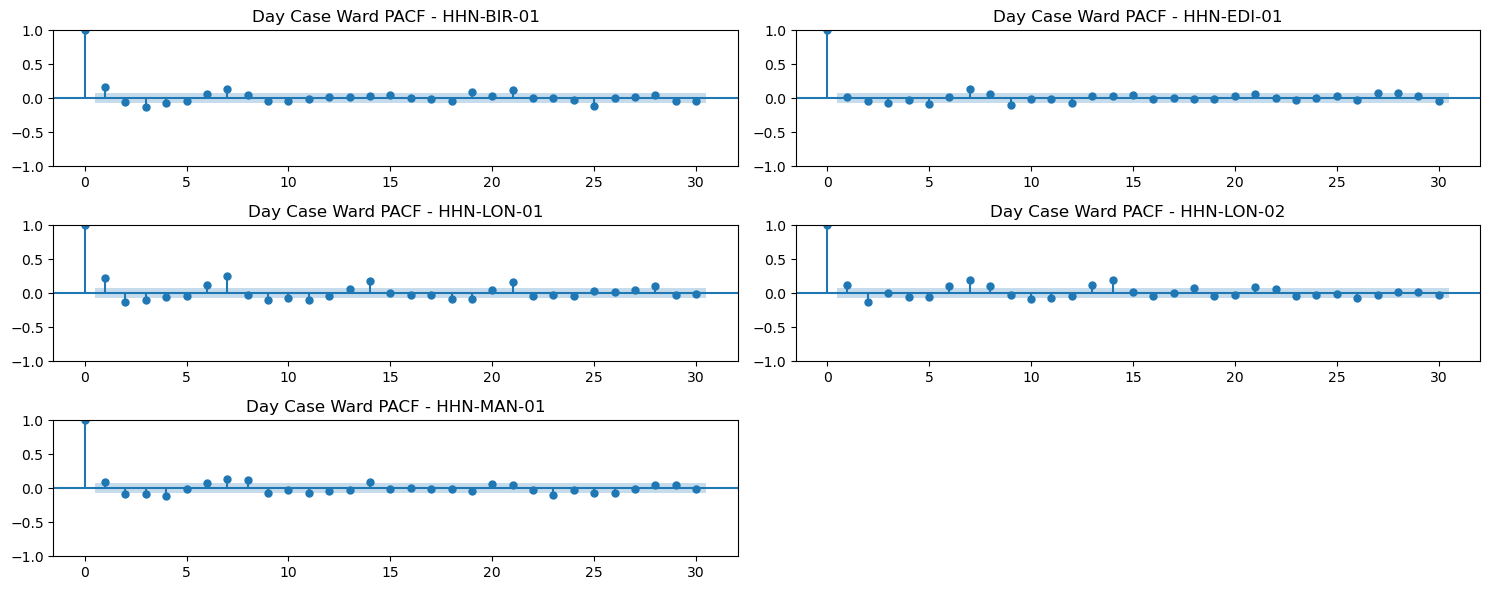

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(day_case["hospital_id"].unique())):

    hospital_data = (day_case[day_case["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"Day Case Ward PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

      Day Case Units have minimal day-to-day memory.
      Yesterday's occupancy has little direct impact on today's occupancy.
      A strong weekly (7-day) seasonal pattern is confirmed across the hospitals.
      Most daily changes are random outside the weekly schedule.
      Weekly planning and scheduled procedures are the main drivers of occupancy.
      A Seasonal ARIMA (SARIMA) model with a 7-day seasonal period is more appropriate than a standard ARIMA model for forecasting Day Case Unit occupancy.

- Seasonal Decomposition for all hospitals

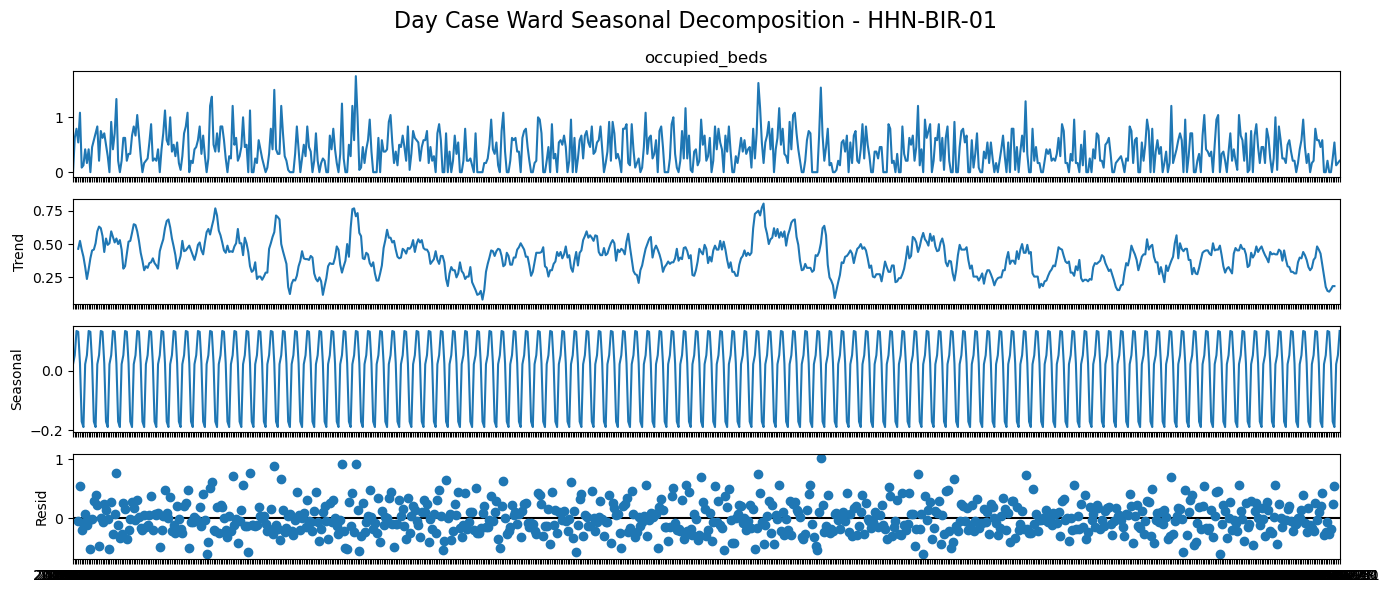

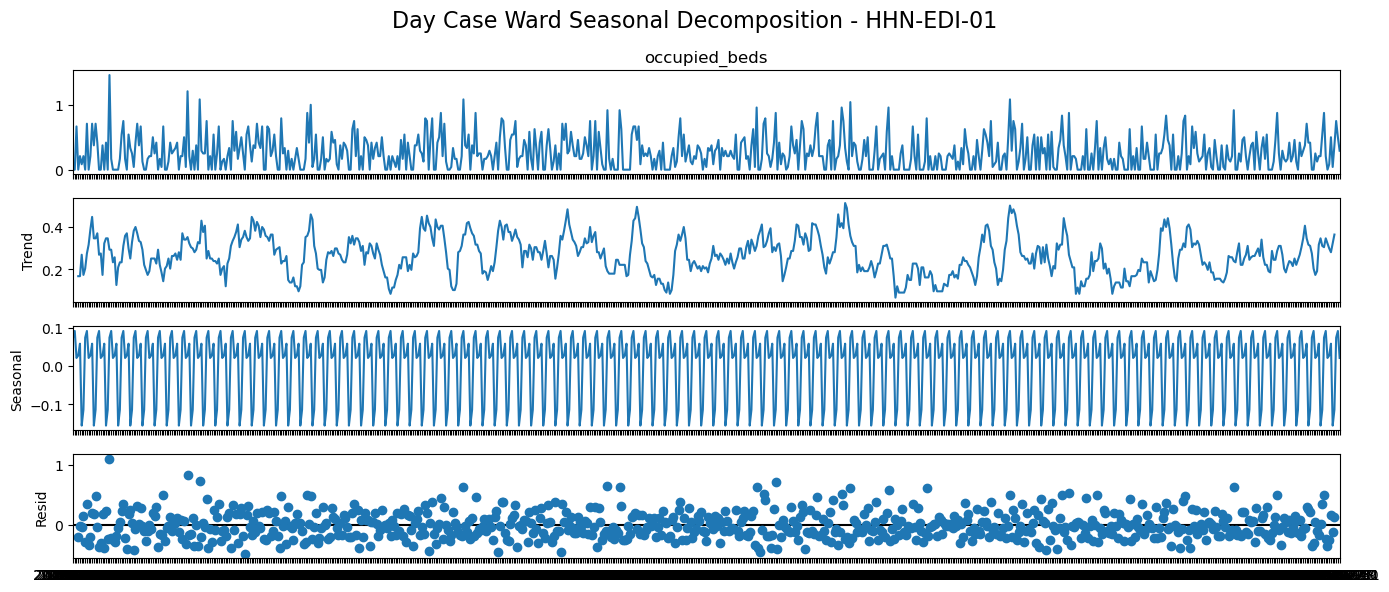

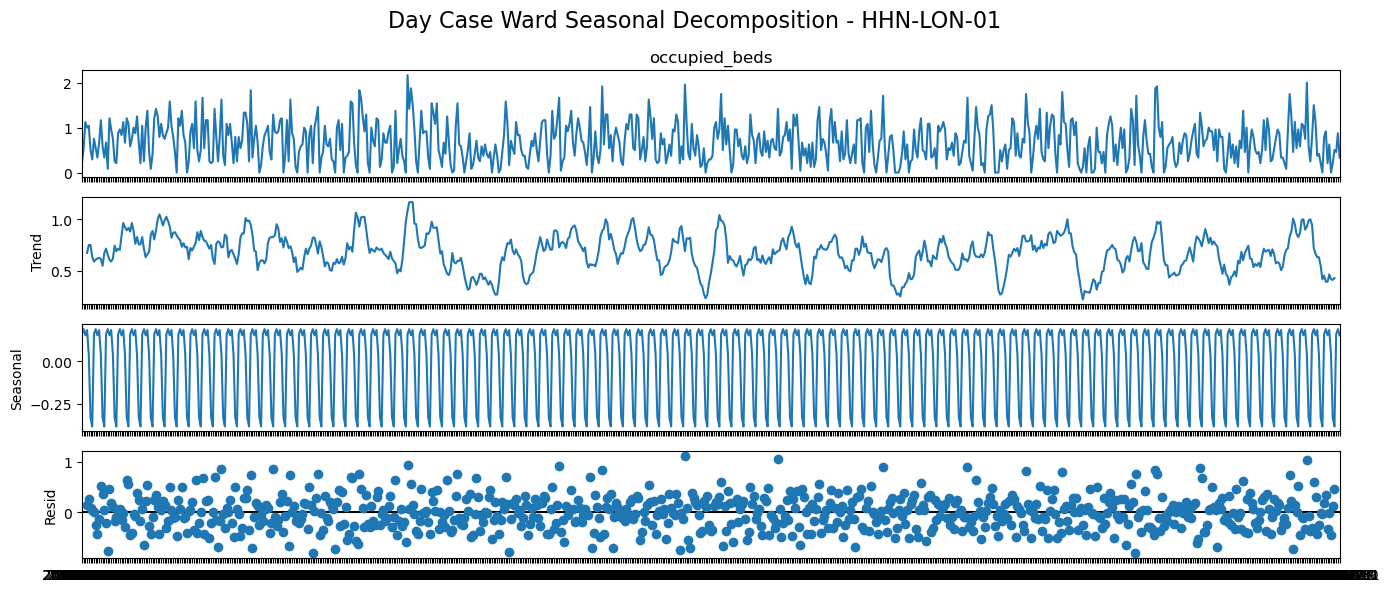

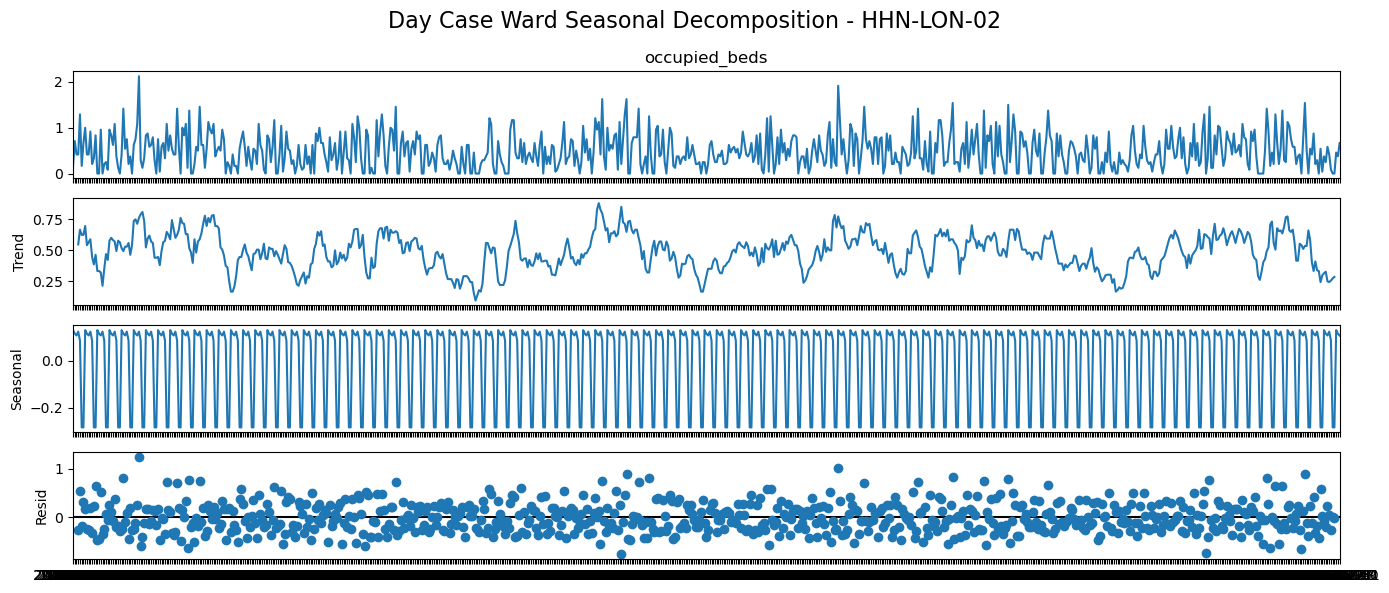

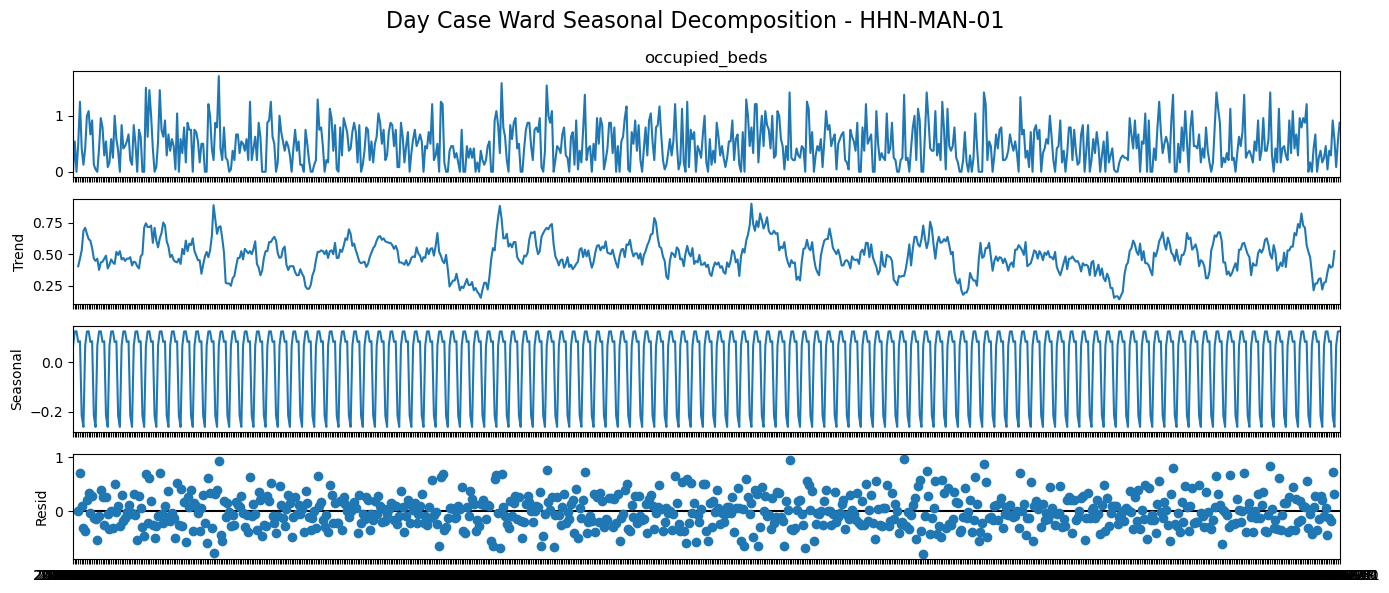

In [22]:
for hospital in sorted(day_case["hospital_id"].unique()):

    hospital_data = (day_case[day_case["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"Day Case Ward Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

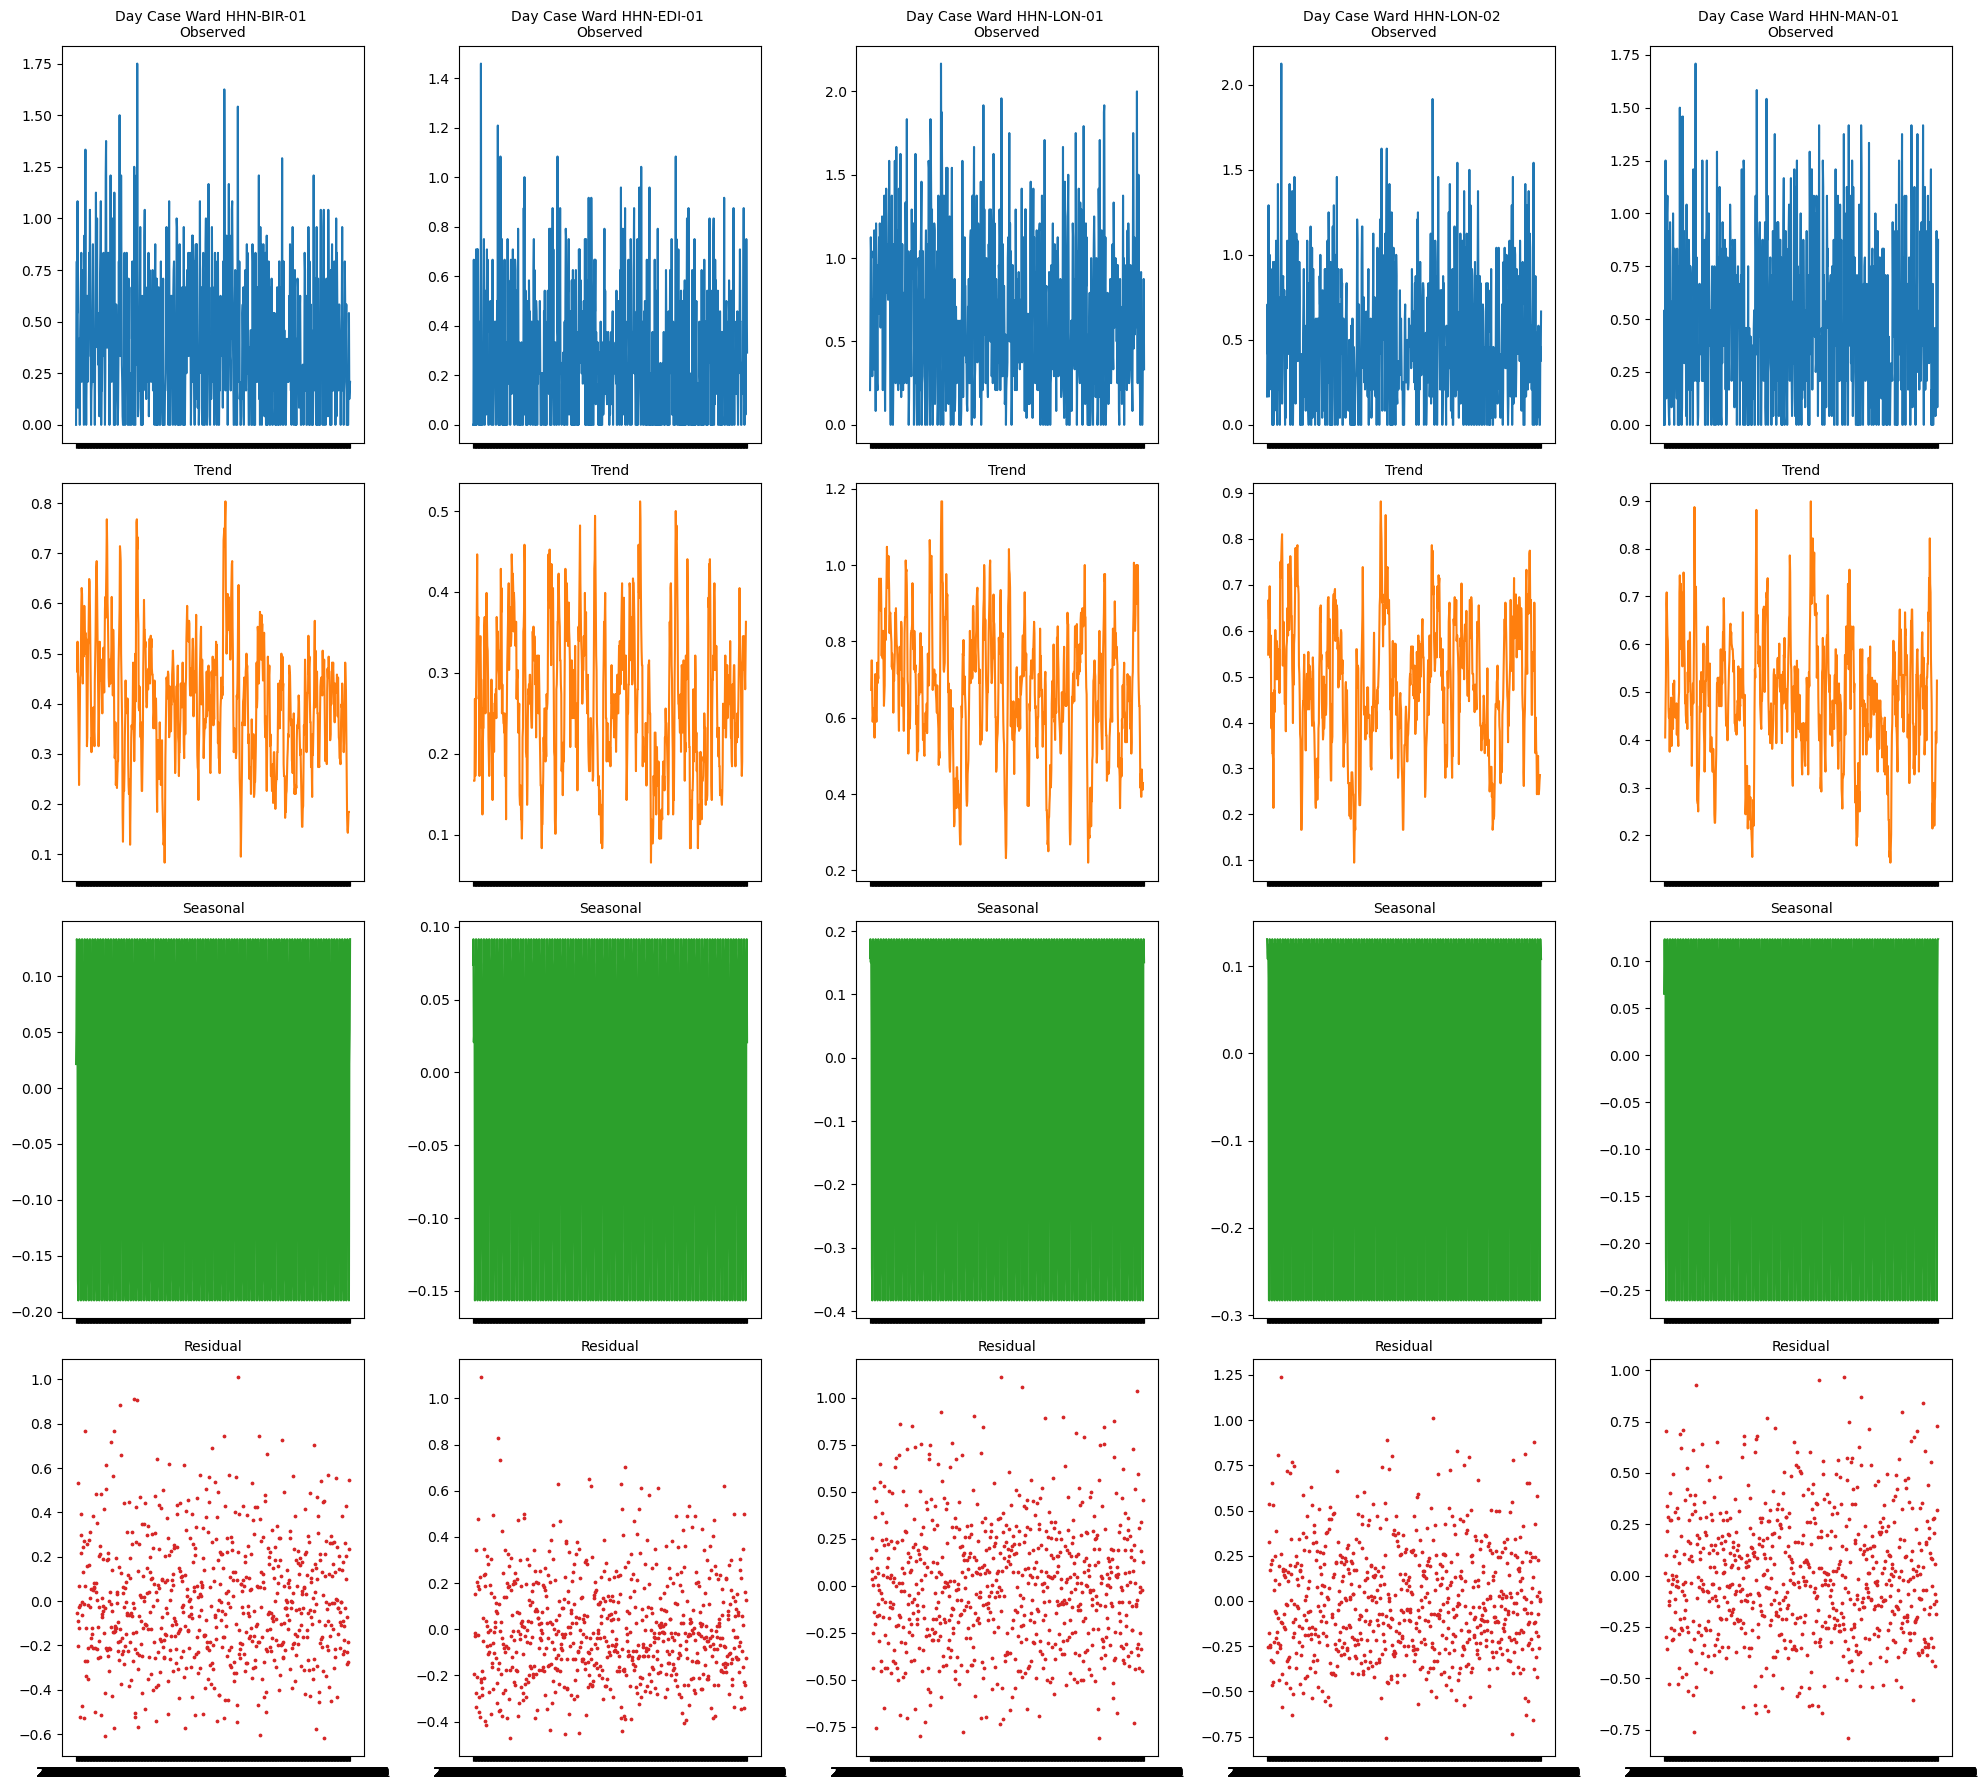

In [24]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(day_case["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = day_case[day_case["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"Day Case Ward {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


     All five hospitals show similar occupancy patterns.
     Bed occupancy changes daily but does not remain at maximum capacity for long periods.
     There is no strong long-term trend, indicating stable demand.
     A strong weekly (7-day) seasonal pattern is present across all hospitals.
     Random fluctuations are relatively small after removing the trend and seasonality.
     A Seasonal ARIMA (SARIMA) model with a 7-day seasonal period is appropriate for forecasting Day Case Unit occupancy across all hospital sites.